In [2]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트 (한글 깨짐 방지)
plt.rcParams['axes.unicode_minus'] = False

mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
mercari_df.head(5)

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


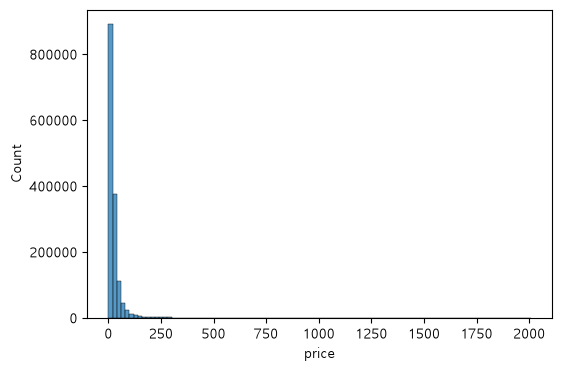

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [3]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

y_labels = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()

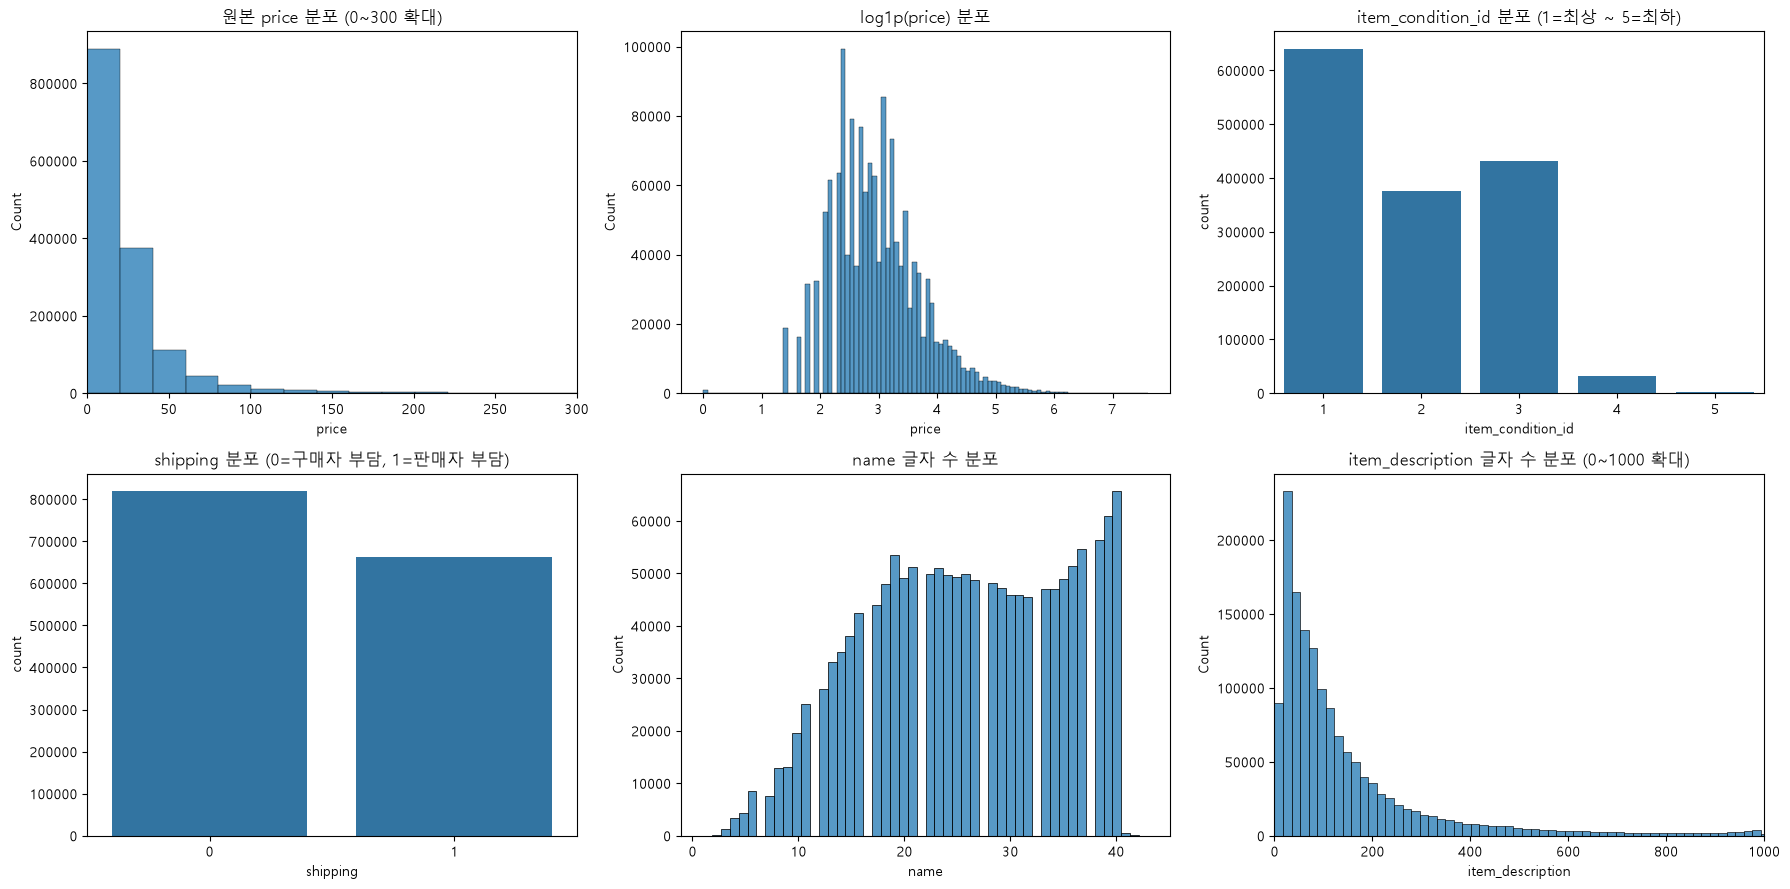

결측치가 있는 컬럼:
                   결측 건수  비율_pct
brand_name        632682   42.68
category_name       6327    0.43
item_description       6    0.00


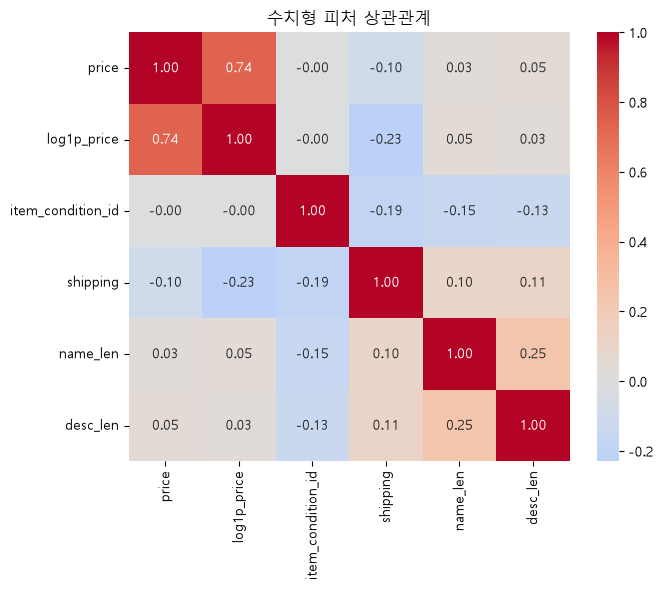

In [4]:
# ── 원시 데이터 EDA 시각화 (가격 필터 / log1p 변환 전에 실행) ──────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1) 원본 price 분포 — 오른쪽 꼬리가 매우 긺(왜도 큼)
sns.histplot(mercari_df['price'], bins=100, ax=axes[0, 0])
axes[0, 0].set_xlim(0, 300)
axes[0, 0].set_title('원본 price 분포 (0~300 확대)')

# 2) log1p(price) 분포 — 종모양에 가까워짐 → 회귀 타깃으로 log1p 사용 근거
sns.histplot(np.log1p(mercari_df['price']), bins=100, ax=axes[0, 1])
axes[0, 1].set_title('log1p(price) 분포')

# 3) 상품 상태(item_condition_id) 분포
sns.countplot(x='item_condition_id', data=mercari_df, ax=axes[0, 2])
axes[0, 2].set_title('item_condition_id 분포 (1=최상 ~ 5=최하)')

# 4) 배송비 부담 주체(shipping) 분포
sns.countplot(x='shipping', data=mercari_df, ax=axes[1, 0])
axes[1, 0].set_title('shipping 분포 (0=구매자 부담, 1=판매자 부담)')

# 5) name 글자 수 분포
sns.histplot(mercari_df['name'].str.len(), bins=50, ax=axes[1, 1])
axes[1, 1].set_title('name 글자 수 분포')

# 6) item_description 글자 수 분포
sns.histplot(mercari_df['item_description'].fillna('').str.len(), bins=60, ax=axes[1, 2])
axes[1, 2].set_xlim(0, 1000)
axes[1, 2].set_title('item_description 글자 수 분포 (0~1000 확대)')

plt.tight_layout()
plt.show()

# 결측치 현황
na = mercari_df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print('결측치가 있는 컬럼:')
print(na.to_frame('결측 건수').assign(비율_pct=lambda d: (d['결측 건수'] / len(mercari_df) * 100).round(2)))

# 수치형 피처 상관관계 (price 는 원본/로그 둘 다)
tmp = pd.DataFrame({
    'price': mercari_df['price'],
    'log1p_price': np.log1p(mercari_df['price']),
    'item_condition_id': mercari_df['item_condition_id'],
    'shipping': mercari_df['shipping'],
    'name_len': mercari_df['name'].str.len(),
    'desc_len': mercari_df['item_description'].fillna('').str.len(),
})
plt.figure(figsize=(7, 6))
sns.heatmap(tmp.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 피처 상관관계')
plt.tight_layout()
plt.show()

In [5]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# 가격이 2000이상인 데이터 제거
mercari_df = mercari_df[mercari_df['price']<2000]
print(f'2000 이상 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)
2000 이상 제거 후 : (1481652, 8)
train_id 제거 후 : (1481603, 7)


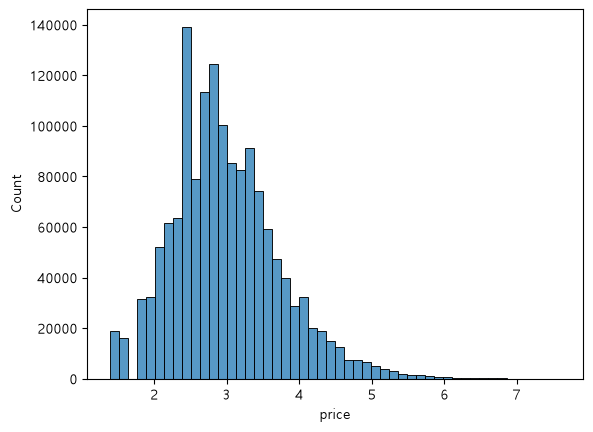

In [6]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [7]:
# category_name 대/중/소분류 분리 + brand_name 결측치 처리
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(split_cat))

# brand_name 결측치는 '노브랜드'라는 의미로 보고 별도 카테고리로 유지
mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')

print('대분류 갯수 :', mercari_df['cat_dae'].nunique())
print('중분류 갯수 :', mercari_df['cat_jung'].nunique())
print('소분류 갯수 :', mercari_df['cat_so'].nunique())
print('브랜드 갯수 :', mercari_df['brand_name'].nunique())

대분류 갯수 : 11
중분류 갯수 : 114
소분류 갯수 : 871
브랜드 갯수 : 4808


In [8]:
# ------------------------------------------------------------------
# [시도했으나 채택하지 않은 방법] category_name.split('/', 2) 로 소분류 정보 보존
# ------------------------------------------------------------------
# category_name 은 원래 "대분류/중분류/소분류" 3단계 구조지만,
# 일부 값은 소분류 이름 자체에 '/' 가 들어 있어 4~5조각으로 쪼개진다.
#   예) "Electronics/Computers & Tablets/iPad/Tablet/eBook Readers"
#
# split('/', 2) (maxsplit=2) 를 쓰면 이런 행의 뒷부분까지 소분류에 살려서
#   cat_so = "iPad/Tablet/eBook Readers" 처럼 통째로 보존할 수 있다.
# 반면 그냥 split('/') + zip(*...) (현재 코드) 은 앞 3조각만 남으므로
#   cat_so = "iPad" 로 뒷부분("Tablet/eBook Readers")이 버려진다.
#   (zip 이 가장 짧은 3조각에 길이를 맞추고 4~5번째 조각을 잘라내기 때문)
#
# 실제 데이터로 두 방식을 비교한 결과:
#   - 두 방식의 결과가 달라지는 행은 4,385개, 전체 1,481,612행의 0.30% 뿐이다.
#   - Other_Null(카테고리 결측) 행 수는 6,314개(0.43%)로 두 방식이 완전히 동일하다.
#     Other_Null 은 category_name 이 NaN 이라 except 로 빠지는 경우이고 '2' 와 무관하다.
#   - 버려지는 정보에 가격 신호가 거의 없다.
#       · eBook Readers 평균 $75.8  vs  eBook Access(액세서리) 평균 $69.7
#         → 차이 약 $6 인데 표준편차가 ~$100 라 가격 구분에 사실상 의미가 없다.
#       · Dance/Ballet, Indoor/Outdoor Games, Flight/Bomber 등은 해당 소분류의
#         하위 갈래가 하나뿐이라 앞조각만 남겨도 그룹이 섞이지 않는다(손실 0).
#   - name / item_description 텍스트 피처가 "kindle", "case" 같은 단어로 같은 정보를
#     이미 담고 있어, 카테고리에서 일부가 빠져도 모델이 보완할 수 있다.
#   - 정보 손실은 신호를 '빼기만' 할 뿐 노이즈를 더하지 않으므로,
#     최악의 경우에도 점수에 미치는 영향은 측정하기 어려울 만큼 작다.
#
# 결론: maxsplit=2 로 얻는 이득이 미미하고 코드 의도만 복잡해지므로 채택하지 않는다.
#       위 셀처럼 split('/') 를 그대로 쓰고, 4~5번째 조각은 버린다(소분류는 첫 조각만 유지).
# ------------------------------------------------------------------


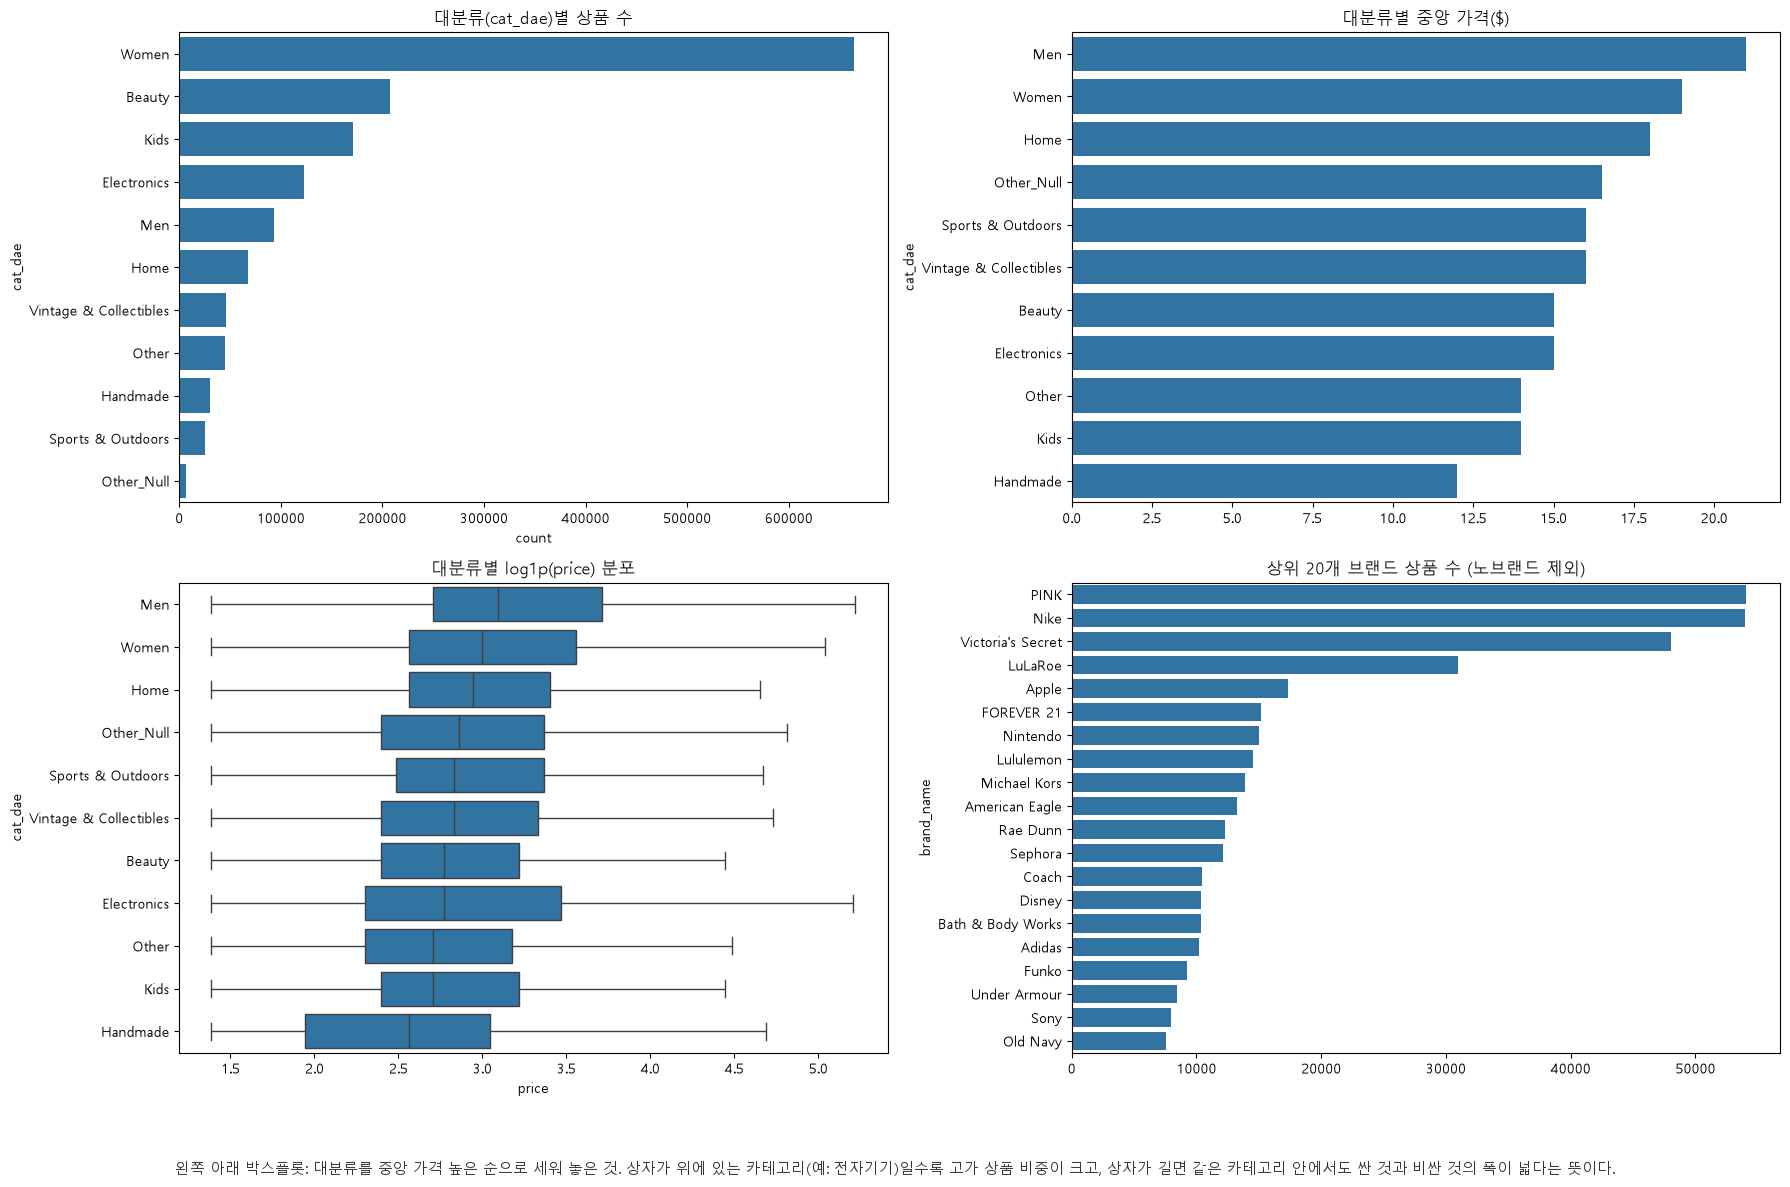

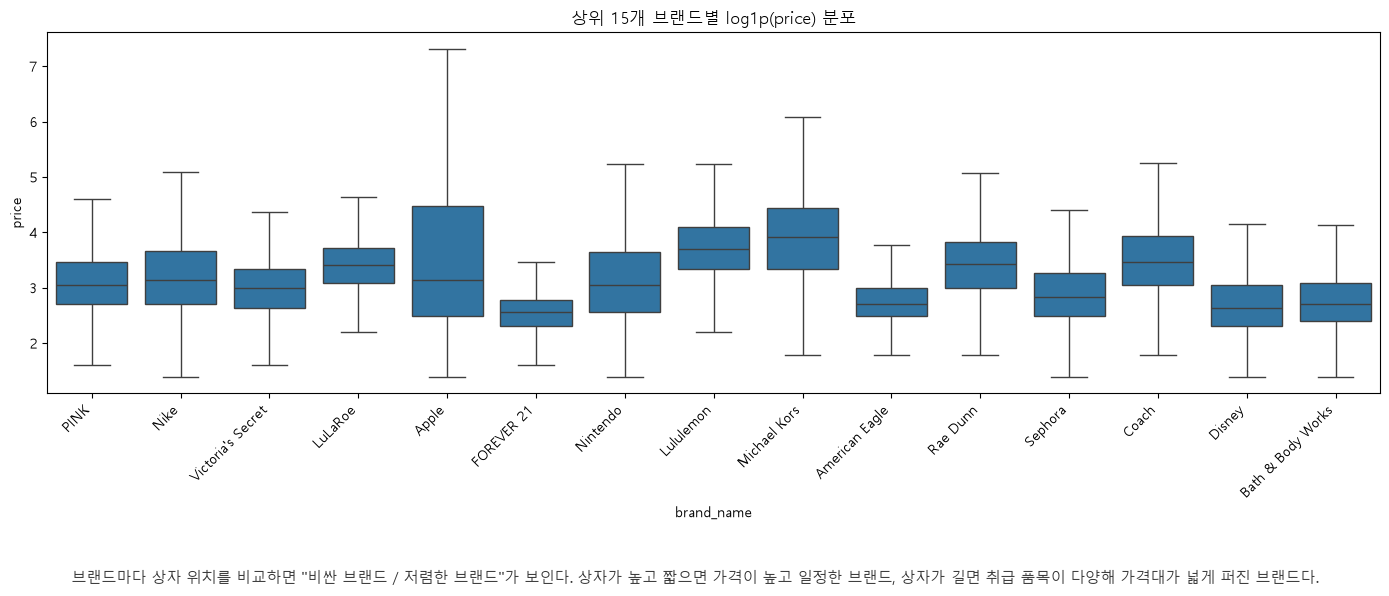

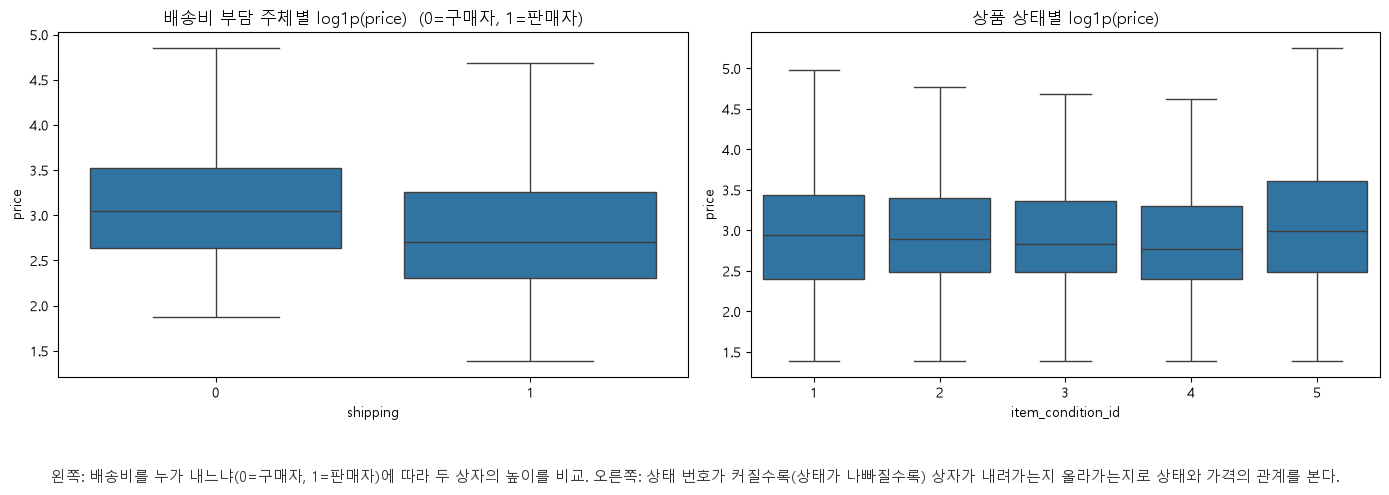

In [9]:
# ── 카테고리 · 브랜드별 가격 시각화 ───────────────────────────────
# [박스플롯 읽는 법]
#   · 상자 가운데 선 = 중앙값(딱 절반 지점). 상자 아래변/위변 = 하위 25% / 상위 25% 지점.
#   · 상자 = 그 그룹 상품의 '가운데 50%' 가 들어오는 가격 구간.
#   · 상자에서 뻗은 수염 = 대략적인 정상 범위(극단 이상치 점은 showfliers=False 로 생략).
#   · 상자가 위에 있을수록 그 그룹은 전반적으로 비싸고, 상자·수염이 길수록 그룹 안 가격 편차가 크다.
#   · y축은 log1p(price) 라서 눈금 1 칸 차이 ≈ 실제 가격 약 2.7배 차이.
# 주의: 이 시점의 mercari_df['price'] 는 이미 log1p 변환된 값이다.
price_won = np.expm1(mercari_df['price'])  # 막대그래프 가독성을 위해 원($) 스케일로 복원

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) 대분류(cat_dae)별 상품 수
cnt_order = mercari_df['cat_dae'].value_counts().index
sns.countplot(y='cat_dae', data=mercari_df, order=cnt_order, ax=axes[0, 0])
axes[0, 0].set_title('대분류(cat_dae)별 상품 수')

# 2) 대분류별 중앙 가격($)
med = price_won.groupby(mercari_df['cat_dae']).median().sort_values(ascending=False)
sns.barplot(x=med.values, y=med.index, ax=axes[0, 1])
axes[0, 1].set_title('대분류별 중앙 가격($)')

# 3) 대분류별 log1p(price) 분포
sns.boxplot(x='price', y='cat_dae', data=mercari_df, order=med.index,
            showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('대분류별 log1p(price) 분포')

# 4) 상위 20개 브랜드 상품 수 (노브랜드 Other_Null 제외)
has_brand = mercari_df['brand_name'] != 'Other_Null'
top_brand = mercari_df.loc[has_brand, 'brand_name'].value_counts().head(20)
sns.barplot(x=top_brand.values, y=top_brand.index, ax=axes[1, 1])
axes[1, 1].set_title('상위 20개 브랜드 상품 수 (노브랜드 제외)')

plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(0.5, 0.015, wrap=True, ha='center', va='bottom', fontsize=11, color='#333333',
         s='왼쪽 아래 박스플롯: 대분류를 중앙 가격 높은 순으로 세워 놓은 것. 상자가 위에 있는 카테고리(예: 전자기기)일수록 '
           '고가 상품 비중이 크고, 상자가 길면 같은 카테고리 안에서도 싼 것과 비싼 것의 폭이 넓다는 뜻이다.')
plt.show()

# 상위 15개 브랜드의 가격 분포
top15 = mercari_df.loc[has_brand, 'brand_name'].value_counts().head(15).index
fig = plt.figure(figsize=(14, 6))
sns.boxplot(x='brand_name', y='price', order=top15, showfliers=False,
            data=mercari_df[mercari_df['brand_name'].isin(top15)])
plt.xticks(rotation=45, ha='right')
plt.title('상위 15개 브랜드별 log1p(price) 분포')
plt.tight_layout(rect=[0, 0.1, 1, 1])
fig.text(0.5, 0.015, wrap=True, ha='center', va='bottom', fontsize=11, color='#333333',
         s='브랜드마다 상자 위치를 비교하면 "비싼 브랜드 / 저렴한 브랜드"가 보인다. 상자가 높고 짧으면 가격이 높고 일정한 브랜드, '
           '상자가 길면 취급 품목이 다양해 가격대가 넓게 퍼진 브랜드다.')
plt.show()

# shipping / item_condition_id 별 가격
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='shipping', y='price', data=mercari_df, showfliers=False, ax=axes[0])
axes[0].set_title('배송비 부담 주체별 log1p(price)  (0=구매자, 1=판매자)')
sns.boxplot(x='item_condition_id', y='price', data=mercari_df, showfliers=False, ax=axes[1])
axes[1].set_title('상품 상태별 log1p(price)')
plt.tight_layout(rect=[0, 0.12, 1, 1])
fig.text(0.5, 0.02, wrap=True, ha='center', va='bottom', fontsize=11, color='#333333',
         s='왼쪽: 배송비를 누가 내느냐(0=구매자, 1=판매자)에 따라 두 상자의 높이를 비교. '
           '오른쪽: 상태 번호가 커질수록(상태가 나빠질수록) 상자가 내려가는지 올라가는지로 상태와 가격의 관계를 본다.')
plt.show()

In [10]:
# ==================================================================
# name / item_description 텍스트 정제를 하는 이유
# ==================================================================
# name, item_description 은 판매자가 자유롭게 입력한 문자열이라 모델이 그대로는
# 계산에 쓸 수 없다. 문자열 컬럼을 그대로 회귀 모델에 넣으면
# 'could not convert string to float' 에러가 난다. 결국 CountVectorizer /
# TfidfVectorizer 로 숫자 벡터로 바꿔야 하는데, 정제 없이 원문 그대로
# 벡터화하면 아래 문제가 생긴다.
#
# 1. 대소문자·형태 차이로 같은 단어가 다른 단어로 취급됨
#    "Nike", "NIKE", "nike" 는 의미가 같은데 정제 없이 벡터화하면 서로 다른
#    3개의 피처로 쪼개져 어휘 사전만 커지고 패턴 학습이 흐려진다.
#    → text_cleaning() 에서 전부 소문자로 통일.
#
# 2. 특수문자·이모지는 노이즈일 뿐 신호가 아님
#    "!!!", "❤️", "@" 같은 기호는 상품의 실제 특징(브랜드·종류·상태)과
#    무관한데, 그대로 두면 불필요한 피처가 생기거나 단어 경계를 깨뜨린다.
#    → 정규식으로 영문자/숫자/공백 외 문자는 전부 제거.
#    단, 숫자는 지우지 않는다. 처음엔 영문자만 남기는 정규식([^a-z\s])을
#    썼는데, "The pale pink is a 1X, and I also have a 3X" 같은 문장에서
#    사이즈 1X / 3X 가 둘 다 의미 없는 "x" 로 뭉개져 구분이 안 되는 문제가
#    있었다. 사이즈·수량 같은 숫자도 가격에 영향을 줄 수 있는 신호라
#    [^a-z0-9\s] 로 바꿔 숫자를 보존했다.
#
# 3. 여러 개의 공백은 하나로 정리
#    사람이 입력한 텍스트라 공백이 중복되거나 삐뚤빼뚤 들어가는데, 이후
#    토큰화 단계에서 빈 토큰이 생기지 않도록 공백을 하나로 정규화한다.
#
# 4. 토큰화 — 문장을 단어 단위로 쪼개야 벡터화가 가능
#    CountVectorizer 도 내부적으로 토큰화를 하지만, 불용어 제거 등 커스텀
#    처리를 먼저 적용하기 위해 word_tokenize 로 직접 단어 리스트를 만든다.
#
# 5. 불용어(stopwords) 제거 — 의미 없는 고빈도 단어를 걸러 신호 대 잡음비를 높임
#    the, is, at 처럼 거의 모든 문장에 등장해 상품 간 구분에 도움이 안 되는
#    단어를 제거하면, 어휘 사전이 줄고 가격과 관련 있는 단어(브랜드명, 상태
#    표현 등)에 모델이 더 집중할 수 있다.
#
# 6. 단, 부정어(no, not, nor, never, without)는 불용어에서 제외
#    "no stain"(얼룩 없음, 긍정)과 "stain"(얼룩, 부정)은 정반대 의미인데,
#    no 를 일반 불용어처럼 지우면 두 문장이 똑같이 "stain" 이 되어 의미가
#    뒤집힌다. 그래서 부정 표현은 불용어 목록에서 따로 빼서 보존한다.
#
#
# 정리: 이 정제 과정의 목적은 모델이 이해 못 하는 형태를 이해할 수 있게
#       바꾸되, 가격 예측에 의미 있는 정보(브랜드, 상태, 사이즈, 부정 표현
#       등)는 최대한 보존하는 것이다.
# ==================================================================


In [11]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import pandas as pd
import re
import nltk


from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter


#텍스트 클리닝(소문자/공백)
def text_cleaning(text):
   
    # 소문자로 변환
    text = text.lower()
   
    # 영문자/숫자와 공백을 제외한 문자 제거 (사이즈 표기 등 숫자 정보 보존)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
   
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
   
    return text.strip()


# 불용어 세팅
stop_words = set(stopwords.words('english'))


# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words

In [12]:
# ------------------------------------------------------------------
# [검증] 숫자 보존 [^a-z0-9\s] vs 숫자 제거 [^a-z\s] — 실제 모델 영향 비교
# ------------------------------------------------------------------
# 위 2번 근거("사이즈·수량 같은 숫자도 가격 신호가 될 수 있다")를 데이터로 확인.
# 표본 250,000행(train 200K / test 50K), 나머지 조건(카테고리·브랜드 원핫,
# 벡터화 파라미터, split, train/test 분리)은 동일하게 두고 Ridge 로 A/B 테스트.
# (RMSLE = 타깃이 log1p(price) 이므로 로그 공간에서의 RMSE 와 같은 값이다.)
#
#   버전                     숫자 포함 피처 수     Ridge RMSLE
#   숫자 보존  [^a-z0-9\s]         5,550개              0.48463
#   숫자 제거  [^a-z\s]                0개              0.48787
#
#   → 숫자를 제거하면 RMSLE 가 +0.00324 (약 +0.67%) 나빠진다. 숫자 보존이 조금 낫다.
#   → 숫자 제거 시 "1x", "3x", "24k", "100" 같은 토큰 5,550개
#      (전체 어휘 83,534개의 약 6.6%)가 사라지거나 "x", "k" 로 뭉개진다.
#   → 두 모델의 개별 예측값 차이: 평균 0.065 log 단위(≈ 가격의 5~6%), 중앙값 0.039.
#
# 결론: split_cat 의 maxsplit 처럼 영향이 0 은 아니며, RMSLE 기준으로
#       숫자 보존([^a-z0-9\s])이 일관되게 유리하다. 다만 개선 폭은 ~0.7% 수준.
#
# 주의:
#   - Ridge, 표본 17%, 단일 분할 결과다. 전체 데이터·Lasso·LGBM 에서 크기는
#     달라질 수 있으나 방향(숫자 보존이 유리)은 바뀔 가능성이 낮다.
#   - 참고로 함께 찍은 '원 달러 스케일 RMSE'(expm1 로 되돌린 예측 기준)는 두 버전이
#     반대로 나왔는데(32.28 vs 30.11), 고가 이상치 몇 개에 휘둘린 값이라 신뢰도가 낮다.
#     대회 지표인 RMSLE 기준으로 판단했다.
#   - CV 미실시라 0.003 중 일부는 노이즈일 수 있으나, 어휘 보존량(5,550 vs 0)
#     자체는 실재하는 차이다.
# ------------------------------------------------------------------


In [13]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수
def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    filtered = [
        word for word in tokens
        if word not in stop_words
    ]

    return filtered

# 결측치 처리 + 문자열 변환
mercari_df['item_description'] = (
    mercari_df['item_description']
    .fillna('No description yet')
    .astype(str)
)

# 클렌징 + 토큰화 + 불용어 제거
mercari_df['item_description'] = (
    mercari_df['item_description'].apply(preprocess_text)
)

# 리스트에서 나열형식 변경 (벡터라이저가 안되는 문제 개선)
mercari_df['item_description'] = mercari_df['item_description'].apply(
    lambda x: ' '.join(x)
)
# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
3    new tags leather horses retail stand foot high...
4                    complete certificate authenticity
Name: item_description, dtype: str

In [14]:
# name도 item_description과 동일한 방식(소문자/영문자 정리 + 토큰화 + 불용어 제거)으로 전처리
mercari_df['name'] = mercari_df['name'].astype(str).apply(preprocess_text)
mercari_df['name'] = mercari_df['name'].apply(lambda x: ' '.join(x))

mercari_df['name'].head()

0    mlb cincinnati reds shirt size xl
1     razer blackwidow chroma keyboard
2                       ava viv blouse
3                leather horse statues
4                 24k gold plated rose
Name: name, dtype: str

In [15]:
# train/test 분리 (여기부터는 test를 학습 과정에서 미리 보면 안 됨 -> 분포를 학습하는 인코딩/벡터화는 이 뒤에서 train에만 fit)
X_train, X_test, y_train, y_test = train_test_split(
    mercari_df.drop(columns='price'),
    mercari_df['price'],
    test_size=0.2,
    random_state=42
)

print('X_train:', X_train.shape, '/ X_test:', X_test.shape)

X_train: (1185282, 9) / X_test: (296321, 9)


In [16]:
from sklearn.preprocessing import LabelBinarizer

# 대/중/소분류 + 브랜드명 원핫인코딩 (train에만 fit, test는 transform만 -> 검증 세트 정보 누수 방지)
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_train_cat_dae = lb_cat_dae.fit_transform(X_train['cat_dae'])
X_test_cat_dae = lb_cat_dae.transform(X_test['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_train_cat_jung = lb_cat_jung.fit_transform(X_train['cat_jung'])
X_test_cat_jung = lb_cat_jung.transform(X_test['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_train_cat_so = lb_cat_so.fit_transform(X_train['cat_so'])
X_test_cat_so = lb_cat_so.transform(X_test['cat_so'])

lb_brand = LabelBinarizer(sparse_output=True)
X_train_brand = lb_brand.fit_transform(X_train['brand_name'])
X_test_brand = lb_brand.transform(X_test['brand_name'])

print('cat_dae   :', X_train_cat_dae.shape, X_test_cat_dae.shape)
print('cat_jung  :', X_train_cat_jung.shape, X_test_cat_jung.shape)
print('cat_so    :', X_train_cat_so.shape, X_test_cat_so.shape)
print('brand_name:', X_train_brand.shape, X_test_brand.shape)

cat_dae   : (1185282, 11) (296321, 11)
cat_jung  : (1185282, 114) (296321, 114)
cat_so    : (1185282, 861) (296321, 861)
brand_name: (1185282, 4533) (296321, 4533)


In [17]:
# name/item_description 벡터화 (train에만 fit, test는 transform만 -> 검증 세트 정보 누수 방지)

# name : 짧은 텍스트(평균 26자) -> CountVectorizer
cnt_vec = CountVectorizer(max_features=30000, ngram_range=(1, 3))
X_train_name = cnt_vec.fit_transform(X_train['name'])
X_test_name = cnt_vec.transform(X_test['name'])

# item_description : 긴 텍스트(평균 146자) -> TfidfVectorizer
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3))
X_train_descp = tfidf_descp.fit_transform(X_train['item_description'])
X_test_descp = tfidf_descp.transform(X_test['item_description'])

print('name 벡터화             :', X_train_name.shape, X_test_name.shape)
print('item_description 벡터화 :', X_train_descp.shape, X_test_descp.shape)

name 벡터화             : (1185282, 30000) (296321, 30000)
item_description 벡터화 : (1185282, 50000) (296321, 50000)


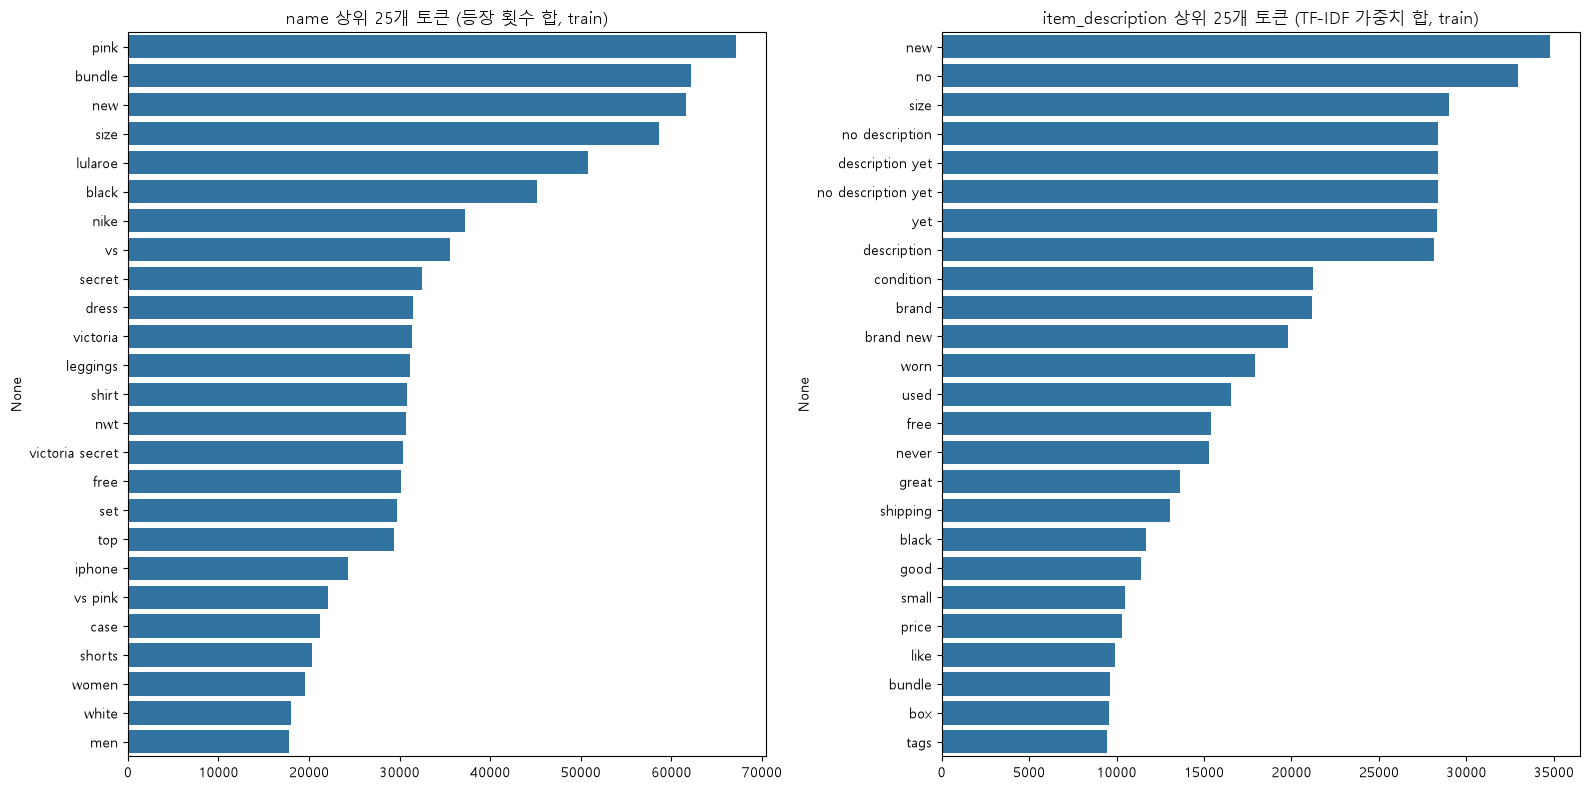

name(Count)              shape=(1185282, 30000)  비영요소 비율=0.01848%
item_description(TF-IDF) shape=(1185282, 50000)  비영요소 비율=0.04885%


In [18]:
# ── 벡터화 결과: name / item_description 상위 빈출 토큰 ────────────
# name: CountVectorizer → 열별 등장 횟수 합
name_freq = np.asarray(X_train_name.sum(axis=0)).ravel()
top_name = pd.Series(name_freq, index=cnt_vec.get_feature_names_out()) \
             .sort_values(ascending=False).head(25)

# item_description: TfidfVectorizer → 열별 TF-IDF 가중치 합
descp_w = np.asarray(X_train_descp.sum(axis=0)).ravel()
top_descp = pd.Series(descp_w, index=tfidf_descp.get_feature_names_out()) \
              .sort_values(ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(x=top_name.values, y=top_name.index, ax=axes[0])
axes[0].set_title('name 상위 25개 토큰 (등장 횟수 합, train)')
sns.barplot(x=top_descp.values, y=top_descp.index, ax=axes[1])
axes[1].set_title('item_description 상위 25개 토큰 (TF-IDF 가중치 합, train)')
plt.tight_layout()
plt.show()

# 토큰 수 대비 실제 사용 밀도 (희소성 확인)
for tag, M in [('name(Count)', X_train_name), ('item_description(TF-IDF)', X_train_descp)]:
    density = M.nnz / (M.shape[0] * M.shape[1])
    print(f'{tag:24s} shape={M.shape}  비영요소 비율={density:.5%}')

In [19]:
from scipy.sparse import hstack, csr_matrix

# item_condition_id, shipping은 이미 숫자형이라 별도 인코딩 없이 그대로 사용
X_train_num = csr_matrix(X_train[['item_condition_id', 'shipping']].values)
X_test_num = csr_matrix(X_test[['item_condition_id', 'shipping']].values)

# 흩어져 있던 피처들을 하나의 행렬로 결합
X_train_final = hstack([
    X_train_num,
    X_train_cat_dae,
    X_train_cat_jung,
    X_train_cat_so,
    X_train_brand,
    X_train_name,
    X_train_descp,
]).tocsr()

X_test_final = hstack([
    X_test_num,
    X_test_cat_dae,
    X_test_cat_jung,
    X_test_cat_so,
    X_test_brand,
    X_test_name,
    X_test_descp,
]).tocsr()

print('X_train_final:', X_train_final.shape)
print('X_test_final :', X_test_final.shape)

X_train_final: (1185282, 85521)
X_test_final : (296321, 85521)


In [20]:
import time
from sklearn.linear_model import Lasso
from lightgbm import LGBMRegressor

# 평가지표: RMSLE = sqrt(mean( (log1p(예측가격) - log1p(실제가격))^2 ))  ← log1p 는 '한 번만'
#
# 이 노트북은 타깃 y 를 앞 셀에서 이미 np.log1p(price) 로 바꿔서 학습한다.
# 그래서 점수를 낼 때는:
#   1) 예측값·정답을 expm1 로 '원 가격($)' 으로 되돌리고
#   2) 거기에 log1p 를 한 번 적용해 RMSLE 를 계산한다.
# (이미 log 된 값에 'log 를 또 씌우는' RMSLE 함수를 그대로 먹이면 log 를 두 번 하게 되므로 주의.)
def rmsle(price_true, price_pred):
    price_pred = np.clip(price_pred, 0, None)  # 음수(가격 < 0) 예측은 0 으로
    return np.sqrt(np.mean((np.log1p(price_pred) - np.log1p(price_true)) ** 2))

# Ridge 는 alpha 5개를 리스트로 두고 5번, Lasso / LGBM 은 기본값으로 1번씩 — 한 셀에서 학습
# 주의: 전체 데이터라 Ridge 5회 + Lasso + LGBM 까지 30분 안팎 걸릴 수 있다.
ridge_alphas = [1.0, 2.0, 3.0, 4.0, 5.0]

models = {f'Ridge(alpha={a})': Ridge(alpha=a) for a in ridge_alphas}
models['Lasso'] = Lasso(alpha=0.001, max_iter=2000)
models['LGBM'] = LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=42)

price_true_test = np.expm1(y_test)  # 정답을 원 가격($) 으로 되돌린 것 (한 번만 계산)

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train_final, y_train)
    pred_log1p = model.predict(X_test_final)          # 모델 출력은 log1p 공간
    price_pred = np.expm1(pred_log1p)                 # 원 가격($) 으로 복원
    score = rmsle(price_true_test, price_pred)
    elapsed = time.time() - start
    results[name] = {'rmsle': score, 'pred': pred_log1p, 'time': elapsed}
    print(f'{name:16s} RMSLE: {score:.4f}  (학습+예측 소요시간: {elapsed:.1f}초)')

# 가장 성능이 좋은 Ridge alpha, 그리고 전체 최고 모델
best_ridge = min((n for n in results if n.startswith('Ridge')), key=lambda n: results[n]['rmsle'])
best_overall = min(results, key=lambda n: results[n]['rmsle'])
print(f'\nRidge 최적 alpha : {best_ridge}  (RMSLE {results[best_ridge]["rmsle"]:.4f})')
print(f'전체 최고 모델   : {best_overall}  (RMSLE {results[best_overall]["rmsle"]:.4f})')

Ridge(alpha=1.0) RMSLE: 0.4576  (학습+예측 소요시간: 94.7초)
Ridge(alpha=2.0) RMSLE: 0.4567  (학습+예측 소요시간: 74.6초)
Ridge(alpha=3.0) RMSLE: 0.4563  (학습+예측 소요시간: 64.0초)
Ridge(alpha=4.0) RMSLE: 0.4561  (학습+예측 소요시간: 57.6초)
Ridge(alpha=5.0) RMSLE: 0.4560  (학습+예측 소요시간: 54.1초)
Lasso            RMSLE: 0.6082  (학습+예측 소요시간: 528.6초)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 306.081704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1161361
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 81202
[LightGBM] [Info] Start training from score 2.980810
LGBM             RMSLE: 0.5104  (학습+예측 소요시간: 772.6초)

Ridge 최적 alpha : Ridge(alpha=5.0)  (RMSLE 0.4560)
전체 최고 모델   : Ridge(alpha=5.0)  (RMSLE 0.4560)


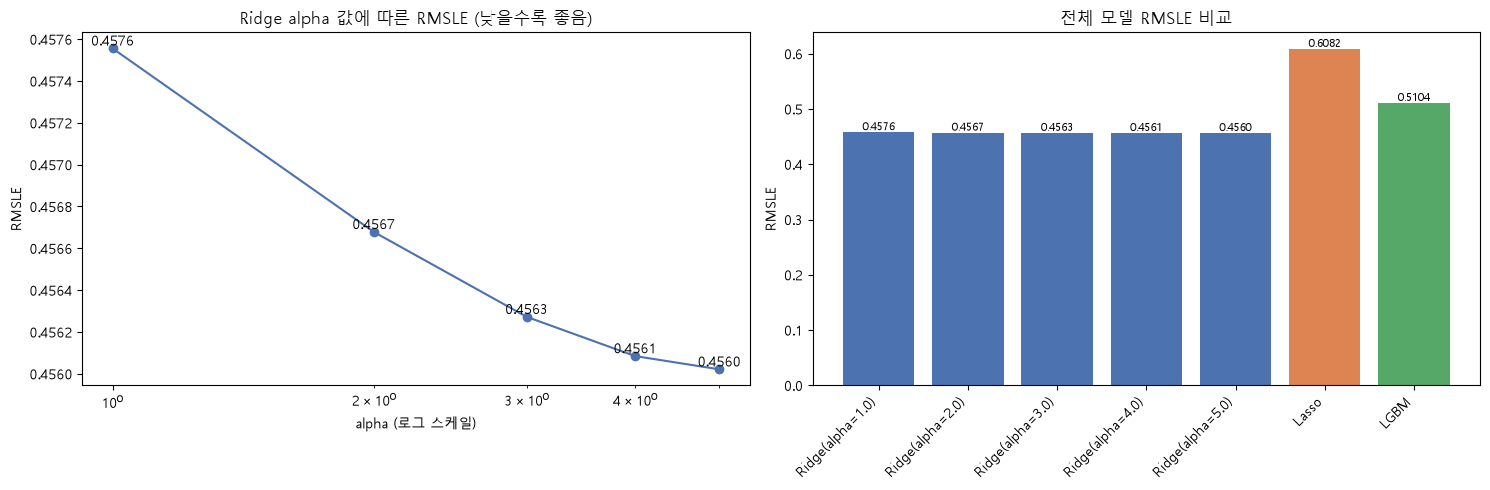

In [21]:
# ── 모델 비교 시각화: Ridge alpha 곡선 + 전체 모델 RMSLE ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) Ridge: alpha 값에 따른 RMSLE
ridge_y = [results[f'Ridge(alpha={a})']['rmsle'] for a in ridge_alphas]
axes[0].plot(ridge_alphas, ridge_y, 'o-', color='#4C72B0')
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha (로그 스케일)')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('Ridge alpha 값에 따른 RMSLE (낮을수록 좋음)')
for x, y in zip(ridge_alphas, ridge_y):
    axes[0].text(x, y, f'{y:.4f}', ha='center', va='bottom')

# (2) 전체 모델 RMSLE 비교 (Ridge 5개 + Lasso + LGBM)
names = list(results.keys())
rmsles = [results[n]['rmsle'] for n in names]
colors = ['#4C72B0'] * len(ridge_alphas) + ['#DD8452', '#55A868']
bars = axes[1].bar(range(len(names)), rmsles, color=colors)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=45, ha='right')
axes[1].set_ylabel('RMSLE')
axes[1].set_title('전체 모델 RMSLE 비교')
for b, r in zip(bars, rmsles):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height(), f'{r:.4f}',
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
# ==================================================================
# [분석] Lasso 의 RMSLE 가 Ridge / LGBM 보다 높게 나오는 이유
# ==================================================================
# (RMSLE = 타깃이 log1p(price) 이므로 로그 공간에서의 RMSE 와 같은 값이다.)
#
# 예시 실행(단일 Ridge) 기준:  Ridge 0.4576  <  LGBM 0.5104  <  Lasso 0.6082   (RMSLE, 낮을수록 좋음)
#
# 같은 파이프라인을 표본 250,000행(train 200K / test 50K)으로 재현해 진단한 값:
#
#   모델                        RMSLE        0이 아닌 계수(실제 사용 피처)     비고
#   Ridge(alpha=1.0)              0.4950        83,486 / 83,486  (전부)
#   Lasso(alpha=0.001)            0.6131           152 / 83,486  (0.2%)      n_iter=788, 수렴 완료
#   기준선(train 평균만 예측)      0.7514              0                     = y_test 표준편차
#
#   → Lasso 의 오차(0.6131)는 Ridge(0.4950)보다 "평균만 찍는 기준선"(0.7514)에
#     더 가깝다. 즉 과대적합이 아니라 심한 '과소적합(underfit)' 이다.
#
# ------------------------------------------------------------------
# 원인 1. L1 페널티는 계수를 '정확히 0' 으로 만든다 — 그런데 이 문제의 신호는
#         소수 피처에 몰려 있지 않고 수천 개의 단어·브랜드·카테고리에 얇게 퍼져 있다.
#   - 가격은 "new", "nwt", 브랜드명, n-gram 등 아주 많은 '약한 신호의 합' 으로 결정된다.
#   - Lasso(L1)는 83,486개 피처 중 152개만 남기고 나머지 99.8% 를 0 으로 없앴다.
#     개별적으로는 약하지만 실재하는 신호 대부분을 통째로 버리므로 underfit 이 된다.
#   - Ridge(L2)는 계수를 0 으로 만들지 않고 '축소' 만 한다. 8만여 개 피처가 전부
#     작은 가중치로 살아남아 더해지므로 이 문제의 실제 구조와 잘 맞는다.
#   - 그래서 bag-of-words 류 고차원 희소 텍스트 회귀에서는 Ridge 가 Lasso 를
#     이기는 것이 일반적이다.
#
# 원인 2. alpha=0.001 은 L1 에게 지나치게 강하다. 그리고 Ridge 와 Lasso 의
#         alpha 는 애초에 같은 척도가 아니다.
#   - Ridge 목적함수:  ||y - Xw||^2 / 2n  +  alpha * sum(w^2)
#   - Lasso 목적함수:  ||y - Xw||^2 / 2n  +  alpha * sum(|w|)
#   - sum(|w|) 와 sum(w^2) 는 성질이 달라 같은 alpha 라도 규제 강도가 전혀 다르다.
#     L1 은 잔차와의 상관이 alpha 문턱보다 약한 피처를 곧바로 0 으로 죽이는데,
#     8만여 개의 약한 상관 피처에는 이 문턱이 사실상 대부분을 쓸어버린다.
#   - 결과적으로 살아남은 152개(강한 브랜드/카테고리 더미 위주)만으로 예측하게 되어
#     "몇 개 더미 + 평균" 수준의 모델이 되고 RMSLE 가 기준선 쪽으로 밀린다.
#
# 원인 3. (확인함) 수렴 실패가 아니다.
#   - n_iter=788 < max_iter=2000 이고 ConvergenceWarning 도 없었다.
#   - max_iter 를 10,000 으로 올려도 결과가 완전히 동일(RMSLE 0.6131, 계수 152개).
#   - 즉 max_iter=2000 은 충분하며, 낮은 점수는 '덜 학습돼서' 가 아니라 L1 해(解)
#     자체가 그렇게 생긴 것이다. (학습이 500초 넘게 걸린 건 8만여 피처를 좌표하강으로
#     한 번 훑는 비용이 클 뿐, 반복 횟수가 많아서가 아니다.)
#
# 원인 4. n-gram 피처의 다중공선성이 L1 에 특히 불리하다.
#   - "new", "brand new", "new with tags", "nwt" 처럼 서로 강하게 상관된 피처가 많다.
#   - L1 은 상관된 무리에서 하나만 남기고 나머지를 0 으로 만들며, 그 선택도
#     표본이 바뀌면 흔들린다. L2 는 무리 전체에 가중치를 나눠 분산이 작고 일반화가 낫다.
#   - ElasticNet(L1+L2)이 바로 이 문제를 완화하려고 나온 것이다.
#
# 원인 5. LGBM(0.5104)이 Lasso 보다 나은 이유.
#   - 트리는 개별 피처로 분기하며 도움이 되는 만큼 피처를 쓴다(LightGBM 로그상
#     81,202개 사용). alpha=0.001 Lasso 처럼 어휘를 통째로 버리지 않는다.
#   - 다만 튜닝 없는 기본 파라미터 + 극단적 원핫/n-gram 희소성은 부스팅의 강점
#     영역이 아니라서, Ridge 는 못 넘고 Ridge 와 Lasso 사이에 위치한다.
#
# ------------------------------------------------------------------
# 정리: Lasso 가 나쁜 건 알고리즘 탓도 수렴 탓도 아니다. "이 문제는 신호가 넓게
#       퍼진 dense 한 문제인데, L1 + 강한 alpha 로 피처를 99.8% 잘라내 과소적합"된
#       탓이다. Lasso 를 쓰려면 alpha 를 훨씬 낮추거나(LassoCV) ElasticNet 을
#       쓰면 되지만, 이 데이터에서는 Ridge 가 가장 자연스럽고 단순한 좋은 기준선이다.
#
# 주의: 위 진단 수치는 전체의 17% 표본·단일 분할 결과라 절대값은 본 실행과
#       다르다. 그러나 모델 간 순서와 "계수 152개" 라는 원인 구조는 동일하게 재현된다.
# ==================================================================


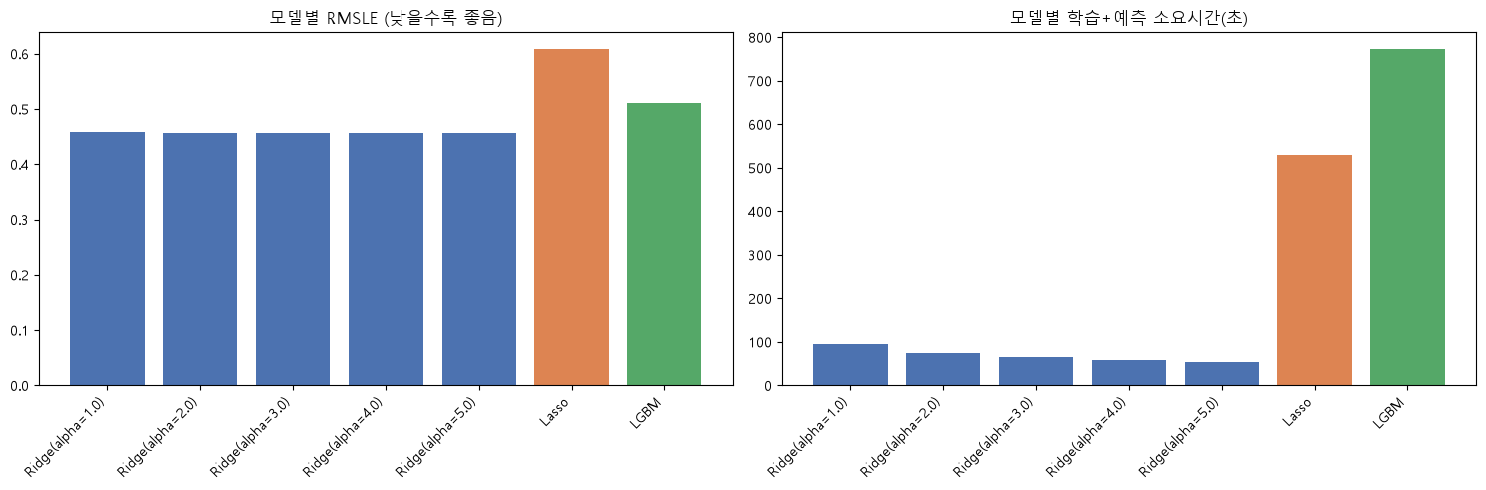

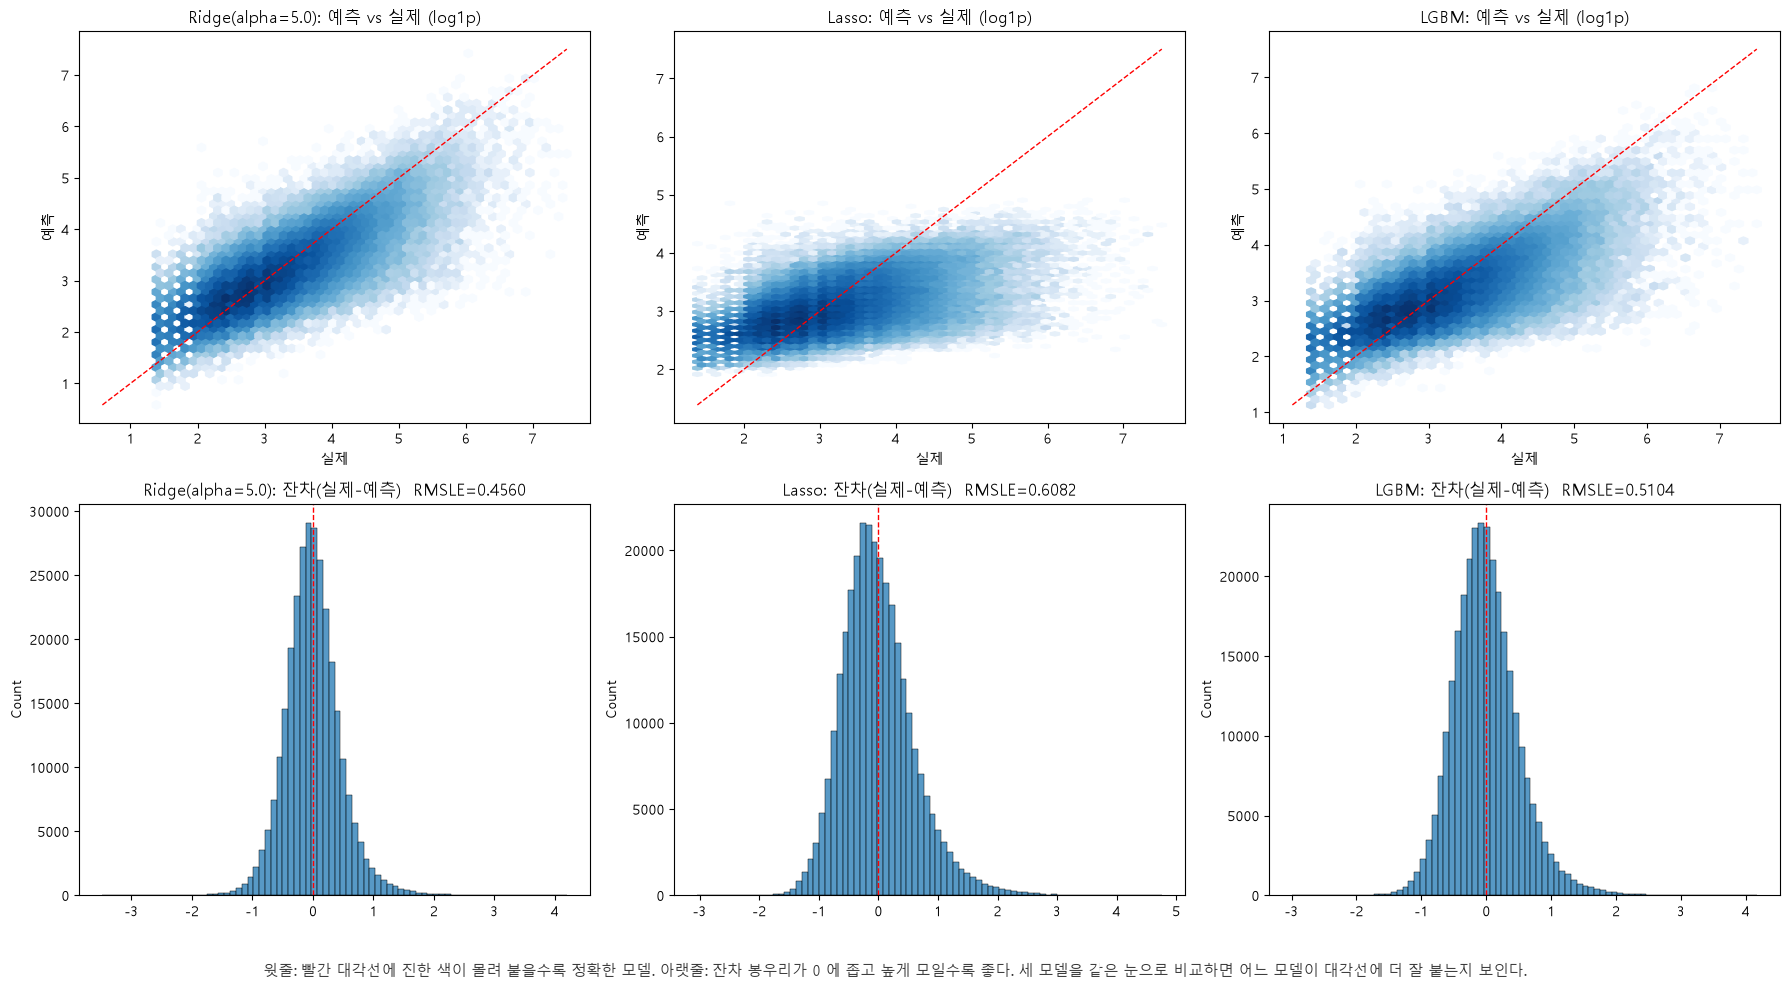

In [23]:
# ── 모델 성능 · 오차 진단 시각화 ─────────────────────────────────
all_names = list(results.keys())
colors = ['#4C72B0'] * len(ridge_alphas) + ['#DD8452', '#55A868']

# 1) RMSLE + 학습시간 비교 (Ridge 5개 + Lasso + LGBM 전체)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(range(len(all_names)), [results[n]['rmsle'] for n in all_names], color=colors)
axes[0].set_xticks(range(len(all_names))); axes[0].set_xticklabels(all_names, rotation=45, ha='right')
axes[0].set_title('모델별 RMSLE (낮을수록 좋음)')
axes[1].bar(range(len(all_names)), [results[n]['time'] for n in all_names], color=colors)
axes[1].set_xticks(range(len(all_names))); axes[1].set_xticklabels(all_names, rotation=45, ha='right')
axes[1].set_title('모델별 학습+예측 소요시간(초)')
plt.tight_layout()
plt.show()

# 2) 예측 vs 실제(hexbin) + 잔차 분포 — 대표 3개 모델(최적 Ridge / Lasso / LGBM)
# [그래프 읽는 법]
#   · 위쪽 hexbin: 가로=실제 log1p(가격), 세로=예측 log1p(가격). 점(육각형)이 빨간 대각선에
#     바싹 붙어 있을수록 정확한 예측. 색이 진한 칸 = 그 구간에 상품이 많이 몰려 있다는 뜻.
#     대각선 위로 벗어나면 과대예측, 아래로 벗어나면 과소예측.
#   · 아래쪽 히스토그램: 잔차(=실제-예측, log1p 공간). 이 잔차들의 제곱평균제곱근이 곧 RMSLE 다.
#     0 근처에 뾰족하게 모일수록 좋고, 봉우리가 0 에서 치우쳐 있으면 과대/과소예측 편향이 있다는 뜻.
rep_names = [best_ridge, 'Lasso', 'LGBM']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, n in enumerate(rep_names):
    pred = results[n]['pred']
    resid = y_test.values - pred
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[0, j].hexbin(y_test, pred, gridsize=50, cmap='Blues', bins='log')
    axes[0, j].plot(lims, lims, 'r--', lw=1)
    axes[0, j].set_title(f'{n}: 예측 vs 실제 (log1p)')
    axes[0, j].set_xlabel('실제'); axes[0, j].set_ylabel('예측')
    sns.histplot(resid, bins=80, ax=axes[1, j])
    axes[1, j].axvline(0, color='r', ls='--', lw=1)
    axes[1, j].set_title(f'{n}: 잔차(실제-예측)  RMSLE={results[n]["rmsle"]:.4f}')
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.015, wrap=True, ha='center', va='bottom', fontsize=11, color='#333333',
         s='윗줄: 빨간 대각선에 진한 색이 몰려 붙을수록 정확한 모델. 아랫줄: 잔차 봉우리가 0 에 좁고 높게 모일수록 좋다. '
           '세 모델을 같은 눈으로 비교하면 어느 모델이 대각선에 더 잘 붙는지 보인다.')
plt.show()

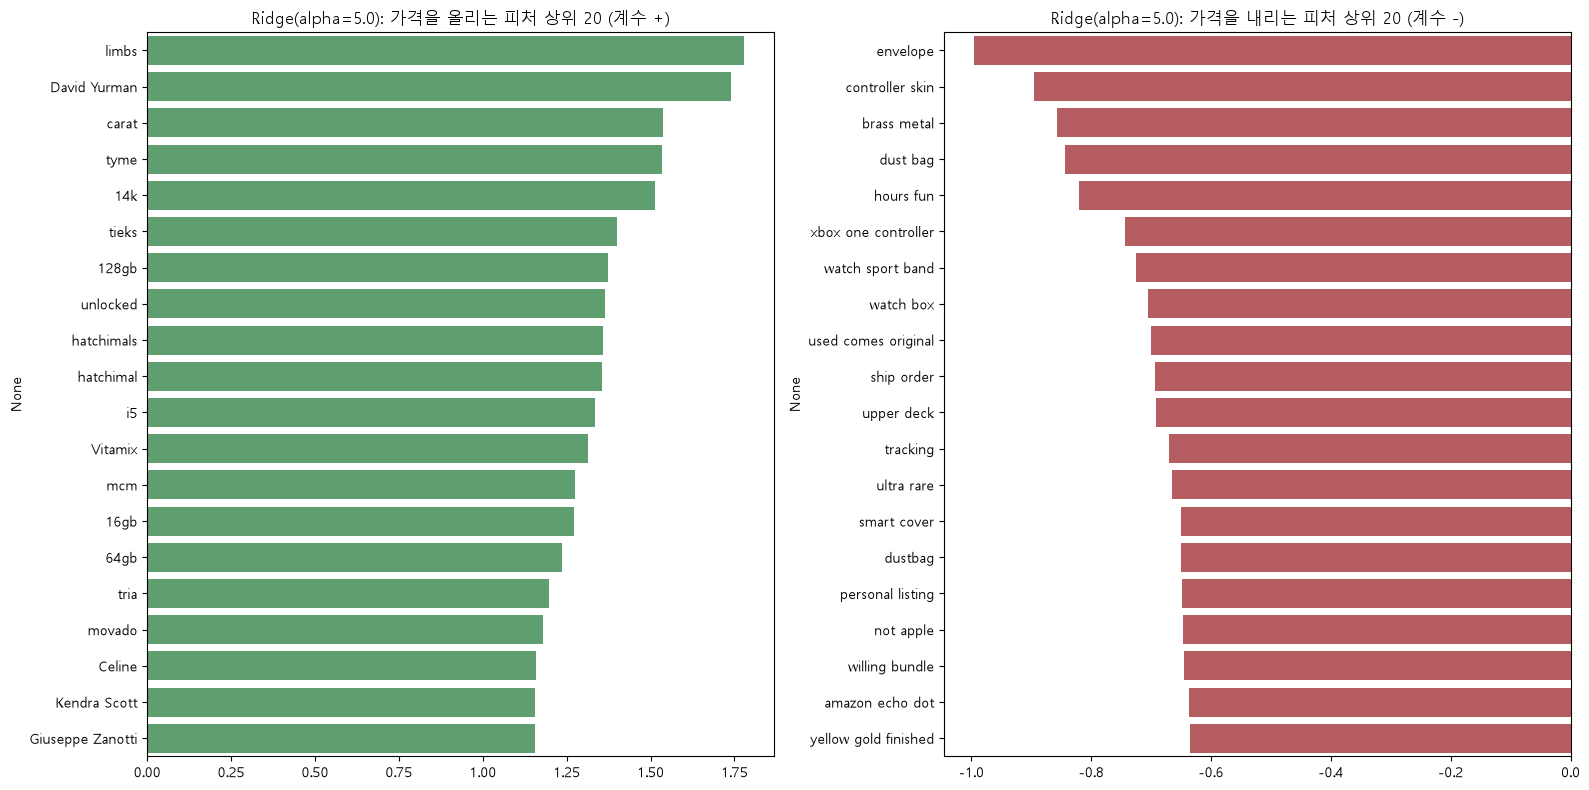

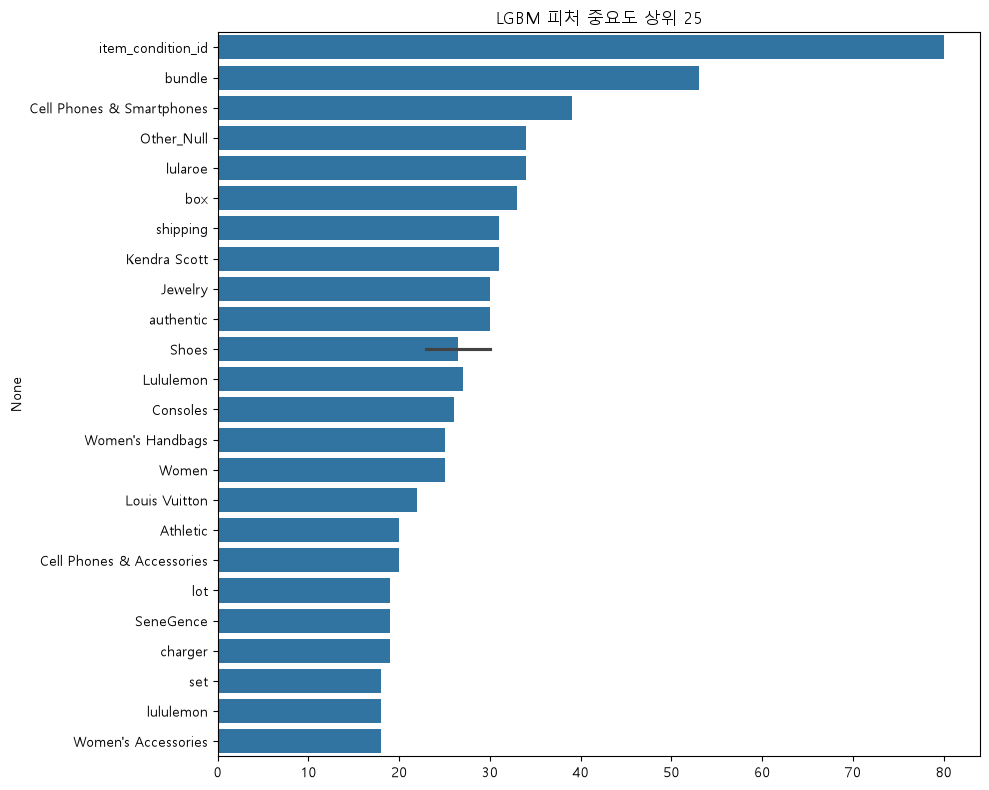

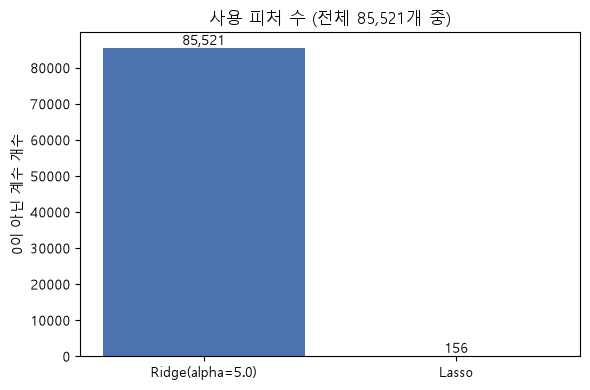

In [24]:
# ── 피처 중요도 / 회귀 계수 시각화 ───────────────────────────────
# hstack 순서대로 피처 이름 재구성 (num → cat_dae → cat_jung → cat_so → brand → name → descp)
feature_names = (
    ['item_condition_id', 'shipping']
    + list(lb_cat_dae.classes_)
    + list(lb_cat_jung.classes_)
    + list(lb_cat_so.classes_)
    + list(lb_brand.classes_)
    + list(cnt_vec.get_feature_names_out())
    + list(tfidf_descp.get_feature_names_out())
)
assert len(feature_names) == X_train_final.shape[1], (len(feature_names), X_train_final.shape[1])

# 1) 최적 Ridge 계수 상위/하위 20 (가격을 올리는 / 내리는 피처)
coef = pd.Series(models[best_ridge].coef_, index=feature_names)
top_pos = coef.sort_values(ascending=False).head(20)
top_neg = coef.sort_values().head(20)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(x=top_pos.values, y=top_pos.index, color='#55A868', ax=axes[0])
axes[0].set_title(f'{best_ridge}: 가격을 올리는 피처 상위 20 (계수 +)')
sns.barplot(x=top_neg.values, y=top_neg.index, color='#C44E52', ax=axes[1])
axes[1].set_title(f'{best_ridge}: 가격을 내리는 피처 상위 20 (계수 -)')
plt.tight_layout()
plt.show()

# 2) LGBM 피처 중요도 상위 25 (split 횟수 기준)
imp = pd.Series(models['LGBM'].feature_importances_, index=feature_names) \
        .sort_values(ascending=False).head(25)
plt.figure(figsize=(10, 8))
sns.barplot(x=imp.values, y=imp.index)
plt.title('LGBM 피처 중요도 상위 25')
plt.tight_layout()
plt.show()

# 3) 최적 Ridge vs Lasso 가 실제로 살려둔(0이 아닌) 계수의 개수 — 과소적합 원인 확인
lasso_nz = int(np.sum(models['Lasso'].coef_ != 0))
ridge_nz = int(np.sum(models[best_ridge].coef_ != 0))
plt.figure(figsize=(6, 4))
plt.bar([best_ridge, 'Lasso'], [ridge_nz, lasso_nz], color=['#4C72B0', '#DD8452'])
plt.ylabel('0이 아닌 계수 개수')
plt.title(f'사용 피처 수 (전체 {X_train_final.shape[1]:,}개 중)')
for i, v in enumerate([ridge_nz, lasso_nz]):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

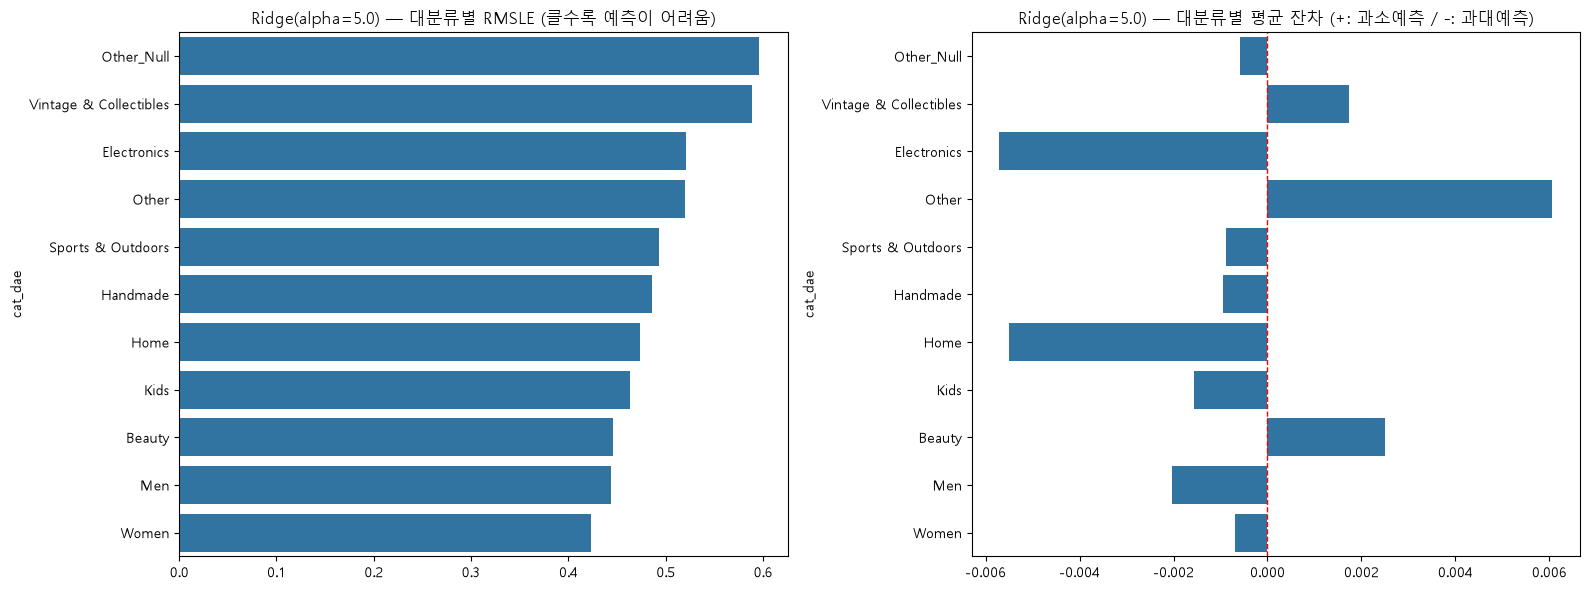

                            건수   RMSLE  편향_평균잔차
cat_dae                                        
Other_Null                1288  0.5953  -0.0006
Vintage & Collectibles    9412  0.5888   0.0017
Electronics              24282  0.5207  -0.0057
Other                     9060  0.5201   0.0061
Sports & Outdoors         5101  0.4930  -0.0009
Handmade                  6194  0.4855  -0.0010
Home                     13641  0.4735  -0.0055
Kids                     34116  0.4638  -0.0016
Beauty                   41622  0.4459   0.0025
Men                      18792  0.4441  -0.0020
Women                   132813  0.4232  -0.0007


In [25]:
# ── 최고 성능 모델의 대분류별 예측 오차 ──────────────────────────
best = min(results, key=lambda n: results[n]['rmsle'])
pred_best = results[best]['pred']

err = pd.DataFrame({
    'cat_dae': X_test['cat_dae'].values,
    'resid': y_test.values - pred_best,   # log1p 공간 잔차
})
by_cat = err.groupby('cat_dae').agg(
    건수=('resid', 'size'),
    RMSLE=('resid', lambda s: np.sqrt(np.mean(s ** 2))),
    편향_평균잔차=('resid', 'mean'),
).sort_values('RMSLE', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=by_cat['RMSLE'].values, y=by_cat.index, ax=axes[0])
axes[0].set_title(f'{best} — 대분류별 RMSLE (클수록 예측이 어려움)')
sns.barplot(x=by_cat['편향_평균잔차'].values, y=by_cat.index, ax=axes[1])
axes[1].axvline(0, color='r', ls='--', lw=1)
axes[1].set_title(f'{best} — 대분류별 평균 잔차 (+: 과소예측 / -: 과대예측)')
plt.tight_layout()
plt.show()

print(by_cat.round(4))